Here, we quantify how well the cell subtype separation matches the actual data, in PLS space. We test those with the following filters:

1) Those from the control script: cell type control --> cell type perturbation
2) Those from the perturbation script: cell type pert 1 --> cell type pert2, in the direction of divergence 

- These two were already filtered for those that have two subtypes in both perturbations
- The pert 1 --> pert 2 condition was further filtered for consistent directionality by ensuring the relative Mahanalobis and Euclidean distances matched. 
- Note since controls (1) mostly converge and pert1->pert2 (2) was coded to go in the diverging direction, we're capturing a balnace of the perturbation shift types

Additional filters:
3) Atleast 25 cells in each subtype - perturbation combination
4) Origin perturbation is in the training and target perturbation is in the test across the 5 folds. If the origin-target train-test pairing is present in multiple folds, we include them all. 


Filters 1 and 2 contained 24 conditions, and adding filters 3 and 4 results in 

In [1]:
import os
import joblib

from tqdm import trange, tqdm

import pandas as pd
import numpy as np
import scanpy as sc

from scipy.spatial.distance import mahalanobis, cosine
from scipy import stats
import statsmodels.api as sm

import torch 

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
import scLEMBAS.utilities as utils
from scLEMBAS.predict import get_prediction

sys.path.insert(1, '../../.')
from McCauley_utils import all_data, initialize_mod_and_trainer

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split, clear_adata

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/us

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


tf_adata.obs['barcodes'] = tf_adata.obs.index.tolist()

pls_models = joblib.load(os.path.join(data_path, 'processed', 'cellsubtype_pls_models_pert.joblib'))
pls_models_ctrl = joblib.load(os.path.join(data_path, 'processed', 'cellsubtype_pls_models.joblib'))
for k, pls_model in pls_models_ctrl.items():
    ct, target_pert = k.split('^')
    cond_label = ct + '^' + ctrl_pert + '->' + target_pert
    pls_models[cond_label] = pls_model
    
del pls_models_ctrl

In [4]:
def add_pls(pls_model, adata):
    adata.uns['pls'] = {'pls_mod': pls_model}
    adata.obsm['X_pls'] = pls_model.transform(adata.X)
    return adata

def order_transition_first(lst):
    return sorted(lst, key=lambda x: 'transition' not in x.lower())


def get_pls_by_subtype(adata, pls_model, origin_pert):
    adata = add_pls(pls_model, adata)
    X_pls = pd.DataFrame(
        adata.obsm['X_pls'], index = adata.obs_names, columns = ['PLS{}'.format(i+1) for i in range(adata.obsm['X_pls'].shape[1])]
    )
    for col in [cat_col, 'secretory_mcc_subsets', pert_col]:
        X_pls[col] = adata.obs[col].copy()
    origin_pert_mask = (X_pls[pert_col] == origin_pert)
    if np.any(origin_pert_mask): # only in the actual data
        X_origin_pert_pls = X_pls[origin_pert_mask].drop(columns = [cat_col, pert_col]).copy()
        X_target_pert_pls = X_pls[~origin_pert_mask].drop(columns = [cat_col, pert_col]).copy()
    else:
        X_origin_pert_pls = None
        X_target_pert_pls = X_pls.drop(columns = [cat_col, pert_col]).copy()
        
    
    return X_origin_pert_pls, X_target_pert_pls


def get_mahanalobis_distance(X):
    subtype_labels = X['secretory_mcc_subsets'].unique()
    g1 = X[X['secretory_mcc_subsets'] == subtype_labels[0]].drop(columns='secretory_mcc_subsets')
    g2 = X[X['secretory_mcc_subsets'] == subtype_labels[1]].drop(columns='secretory_mcc_subsets')

    # means
    m1, m2 = g1.mean().values, g2.mean().values

    # pooled covariance
    S = np.cov(np.vstack([g1.values, g2.values]).T)
    S_inv = np.linalg.inv(S)

    # Mahalanobis distance
    m_distance = mahalanobis(m1, m2, S_inv)
    
    return m_distance

def get_euclidean_distance(X):
    subtype_labels = X['secretory_mcc_subsets'].unique()
    g1 = X[X['secretory_mcc_subsets'] == subtype_labels[0]].drop(columns='secretory_mcc_subsets')
    g2 = X[X['secretory_mcc_subsets'] == subtype_labels[1]].drop(columns='secretory_mcc_subsets')

    # means
    m1, m2 = g1.mean().values, g2.mean().values

    # Euclidean distance
    e_distance = np.linalg.norm(m1 - m2)
    
    return e_distance

def get_cosine_distance(
    X_origin: pd.DataFrame,
    X_target: pd.DataFrame,
    subset_col: str = "secretory_mcc_subsets",
    separate_origin_subtype: bool = False,
) -> float:
    """
    Calculate the cosine distance between two vectors defined by subset centroids
    across two dataframes.

    If separate_origin_subtype is True:
        For each subset, define a vector from that subset's centroid in X_origin
        to the corresponding subset centroid in X_target.

    If separate_origin_subtype is False:
        Use the global centroid of X_origin as the shared origin for both vectors,
        and define vectors from that shared origin to each subset centroid in X_target.

    Assumes:
    - There are exactly two unique values in subset_col.
    - Both dataframes contain the same two subset labels.
    - PLS columns are all columns except subset_col.

    Parameters
    ----------
    X_origin : pd.DataFrame
        Origin dataframe containing PLS columns and subset_col.
    X_target : pd.DataFrame
        Target dataframe containing PLS columns and subset_col.
    subset_col : str, default="secretory_mcc_subsets"
        Column indicating the two subsets.
    separate_origin_subtype : bool, default=False
        Whether to use subtype-specific origin centroids (True) or a shared
        global centroid from X_origin (False).

    Returns
    -------
    float
        Cosine distance between the two vectors.
    """

    pls_cols = [c for c in X_origin.columns if c != subset_col]

    if set(pls_cols) != set([c for c in X_target.columns if c != subset_col]):
        raise ValueError("X_origin and X_target must have the same PLS columns.")

    subset_vals_origin = X_origin[subset_col].dropna().unique()
    subset_vals_target = X_target[subset_col].dropna().unique()

    if len(subset_vals_origin) != 2 or len(subset_vals_target) != 2:
        raise ValueError(f"Both dataframes must have exactly 2 unique values in '{subset_col}'.")

    if set(subset_vals_origin) != set(subset_vals_target):
        raise ValueError("Both dataframes must contain the same subset labels.")

    subset_vals = sorted(subset_vals_origin)

    origin_centroids = X_origin.groupby(subset_col)[pls_cols].mean()
    target_centroids = X_target.groupby(subset_col)[pls_cols].mean()

    if separate_origin_subtype:
        vec_1 = (
            target_centroids.loc[subset_vals[0], pls_cols].values
            - origin_centroids.loc[subset_vals[0], pls_cols].values
        )
        vec_2 = (
            target_centroids.loc[subset_vals[1], pls_cols].values
            - origin_centroids.loc[subset_vals[1], pls_cols].values
        )
    else:
        origin_global_centroid = X_origin[pls_cols].mean().values

        vec_1 = (
            target_centroids.loc[subset_vals[0], pls_cols].values
            - origin_global_centroid
        )
        vec_2 = (
            target_centroids.loc[subset_vals[1], pls_cols].values
            - origin_global_centroid
        )

    if np.allclose(vec_1, 0) or np.allclose(vec_2, 0):
        return np.nan

    return cosine(vec_1, vec_2)




# Quantify Distances for actual model

In [5]:
fn = os.path.join(data_path, 'processed', 'subtype_distance_quantification_with_predictions.csv')

In [31]:
min_obs_per_cond = 15
distances_res = []
if not os.path.isfile(fn):
    trainers_per_fold = {}
    for fold in trange(5):
        fn_trainer = os.path.join(data_path, 'processed', '{}_fold{}trainer_actual.pickle'.format(author, fold))
        trainer = io.read_pickled_object(fn_trainer)
        trainers_per_fold[fold] = trainer
    
    
    
    for (cond_label, pls_model) in tqdm(pls_models.items()):

        # get conditions subsets
        ct, perts = cond_label.split('^')
        origin_pert, target_pert = perts.split('->')

        ct_mask = (tf_adata.obs[cat_col] == ct)
        pert_mask = (tf_adata.obs[pert_col].isin([origin_pert, target_pert]))
        tf_adata_actual = tf_adata[ct_mask & pert_mask].copy()
        min_count_met = np.all(tf_adata_actual.obs.value_counts(['secretory_mcc_subsets', pert_col]) > min_obs_per_cond)
        if not min_count_met:
            continue # return None

        tf_adata_actual = clear_adata(tf_adata_actual)
        cell_subtypes = tf_adata_actual.obs.secretory_mcc_subsets.unique()
        cell_subtypes = order_transition_first(cell_subtypes)

        working_folds = []
        for fold in range(5):
            split = get_split(fold = fold, author = author)

            a = '^'.join([ct, origin_pert]) in split['train_conds']
            b = '^'.join([ct, target_pert]) in split['test_conds']

            if a and b:
                working_folds.append(fold)
        if len(working_folds) == 0:
            continue # return None

        for fold in working_folds:
            ######################## get folds that have origin perturbation in training and target perturbation in test ########################
            trainer = trainers_per_fold[fold]
            mod = trainer.mod

            split = get_split(fold = fold, author = author)

            train_barcodes = split['train_barcodes']
            test_barcodes = split['test_barcodes']

            assert trainer.X_train.index.tolist() == train_barcodes, 'Train barcodes mismatch'
            assert trainer.X_test.index.tolist() == test_barcodes, 'Test barcodes mismatch'

            ######################## subset to conditions of interest ########################
            train_mask = (tf_adata.obs['barcodes'].isin(train_barcodes)) & \
            (tf_adata.obs.condition == '^'.join([ct, origin_pert]))

            test_mask = (tf_adata.obs['barcodes'].isin(test_barcodes)) & \
            (tf_adata.obs.condition == '^'.join([ct, target_pert]))

            cst_mask = (tf_adata.obs['secretory_mcc_subsets'] == cell_subtypes[0])


            ######################## PREDICT EACH SUBTYPE SEPARATELY ########################
            # subtype 1
            tf_adata_predicted_0 = get_prediction(
                mod = mod,
                train_cells = tf_adata[train_mask & cst_mask].obs.barcodes.tolist(),
                test_cells = tf_adata[test_mask].obs.barcodes.tolist(), 
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert, 
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False, 
                max_cells = int(5e3), 
                return_full = False, 
                stim_label_map = None, # special use case for Kang
                predict_from_pert = origin_pert if origin_pert != ctrl_pert else None, # not predicting from control
            )
            tf_adata_predicted_0.obs['secretory_mcc_subsets'] = cell_subtypes[0]

            # subtype 2
            tf_adata_predicted_1 = get_prediction(
                mod = mod,
                train_cells = tf_adata[train_mask & ~cst_mask].obs.barcodes.tolist(),
                test_cells = tf_adata[test_mask].obs.barcodes.tolist(), 
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert, 
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False, 
                max_cells = int(5e3), 
                return_full = False, 
                stim_label_map = None, # special use case for Kang
                predict_from_pert = origin_pert, # not predicting from control
            )
            tf_adata_predicted_1.obs['secretory_mcc_subsets'] = cell_subtypes[1]
            tf_adata_predicted = sc.concat([tf_adata_predicted_0, tf_adata_predicted_1])
            del tf_adata_predicted_0, tf_adata_predicted_1

            # get pls fits
            pls_model = pls_models[ct + '^' + origin_pert + '->' + target_pert]
            tf_adata_predicted = add_pls(pls_model, tf_adata_predicted)
            tf_adata_actual = add_pls(pls_model, tf_adata_actual)


            # get distances in PLS space
            _, X_pls_target_pert_predicted = get_pls_by_subtype(
                adata = tf_adata_predicted, pls_model = pls_model, origin_pert = origin_pert
            )
            assert _ is None
            target_predicted_md = get_mahanalobis_distance(X_pls_target_pert_predicted)
            target_predicted_ed = get_euclidean_distance(X_pls_target_pert_predicted)

            X_pls_origin_pert_actual, X_pls_target_pert_actual = get_pls_by_subtype(
                adata = tf_adata_actual, pls_model = pls_model, origin_pert = origin_pert
            )

            target_actual_md = get_mahanalobis_distance(X_pls_target_pert_actual)
            target_actual_ed = get_euclidean_distance(X_pls_target_pert_actual)

            origin_actual_md = get_mahanalobis_distance(X_pls_origin_pert_actual)
            origin_actual_ed = get_euclidean_distance(X_pls_origin_pert_actual)
            cos_actual = get_cosine_distance(X_pls_origin_pert_actual, X_pls_target_pert_actual)
            cos_pred = get_cosine_distance(X_pls_origin_pert_actual, X_pls_target_pert_predicted)

            distance_dict = {
                'cell_type': ct, 
                'origin_pert': origin_pert, 
                'target_pert': target_pert, 
                'fold': fold, 
                'target_predicted_md': target_predicted_md, 
                'target_predicted_ed': target_predicted_ed, 
                'target_actual_md': target_actual_md, 
                'target_actual_ed': target_actual_ed, 
                'origin_actual_md': origin_actual_md, 
                'origin_actual_ed': origin_actual_ed, 
                'cosine_actual': cos_actual, 
                'cosine_predicted': cos_pred
            }
            distances_res.append(distance_dict)

    distances_res_actual = pd.DataFrame(distances_res)
    distances_res_actual['mod_type'] = 'actual'
    distances_res_actual.to_csv(fn)
else:
    distances_res_actual = pd.read_csv(fn, index_col = 0)




# Repeat for random model to have a baseline comparison

In [7]:
fn = os.path.join(data_path, 'processed', 'subtype_distance_quantification_with_predictions_random.csv')

In [30]:
min_obs_per_cond = 15
distances_res = []

if not os.path.isfile(fn):
    trainers_per_fold = {}
    for fold in trange(5):
        fn_trainer = os.path.join(data_path, 'processed', '{}_fold{}trainer_random.pickle'.format(author, fold))
        trainer = io.read_pickled_object(fn_trainer)
        trainers_per_fold[fold] = trainer
    for (cond_label, pls_model) in tqdm(pls_models.items()):

        # get conditions subsets
        ct, perts = cond_label.split('^')
        origin_pert, target_pert = perts.split('->')

        ct_mask = (tf_adata.obs[cat_col] == ct)
        pert_mask = (tf_adata.obs[pert_col].isin([origin_pert, target_pert]))
        tf_adata_actual = tf_adata[ct_mask & pert_mask].copy()
        min_count_met = np.all(tf_adata_actual.obs.value_counts(['secretory_mcc_subsets', pert_col]) > min_obs_per_cond)
        if not min_count_met:
            continue # return None

        tf_adata_actual = clear_adata(tf_adata_actual)
        cell_subtypes = tf_adata_actual.obs.secretory_mcc_subsets.unique()
        cell_subtypes = order_transition_first(cell_subtypes)

        working_folds = []
        for fold in range(5):
            split = get_split(fold = fold, author = author)

            a = '^'.join([ct, origin_pert]) in split['train_conds']
            b = '^'.join([ct, target_pert]) in split['test_conds']

            if a and b:
                working_folds.append(fold)
        if len(working_folds) == 0:
            continue # return None

        for fold in working_folds:
            ######################## get folds that have origin perturbation in training and target perturbation in test ########################
            trainer = trainers_per_fold[fold]
            mod = trainer.mod

            split = get_split(fold = fold, author = author)

            train_barcodes = split['train_barcodes']
            test_barcodes = split['test_barcodes']

            assert trainer.X_train.index.tolist() == train_barcodes, 'Train barcodes mismatch'
            assert trainer.X_test.index.tolist() == test_barcodes, 'Test barcodes mismatch'

            ######################## subset to conditions of interest ########################
            train_mask = (tf_adata.obs['barcodes'].isin(train_barcodes)) & \
            (tf_adata.obs.condition == '^'.join([ct, origin_pert]))

            test_mask = (tf_adata.obs['barcodes'].isin(test_barcodes)) & \
            (tf_adata.obs.condition == '^'.join([ct, target_pert]))

            cst_mask = (tf_adata.obs['secretory_mcc_subsets'] == cell_subtypes[0])


            ######################## PREDICT EACH SUBTYPE SEPARATELY ########################
            # subtype 1
            tf_adata_predicted_0 = get_prediction(
                mod = mod,
                train_cells = tf_adata[train_mask & cst_mask].obs.barcodes.tolist(),
                test_cells = tf_adata[test_mask].obs.barcodes.tolist(), 
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert, 
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False, 
                max_cells = int(5e3), 
                return_full = False, 
                stim_label_map = None, # special use case for Kang
                predict_from_pert = origin_pert if origin_pert != ctrl_pert else None, # not predicting from control
            )
            tf_adata_predicted_0.obs['secretory_mcc_subsets'] = cell_subtypes[0]

            # subtype 2
            tf_adata_predicted_1 = get_prediction(
                mod = mod,
                train_cells = tf_adata[train_mask & ~cst_mask].obs.barcodes.tolist(),
                test_cells = tf_adata[test_mask].obs.barcodes.tolist(), 
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert, 
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False, 
                max_cells = int(5e3), 
                return_full = False, 
                stim_label_map = None, # special use case for Kang
                predict_from_pert = origin_pert, # not predicting from control
            )
            tf_adata_predicted_1.obs['secretory_mcc_subsets'] = cell_subtypes[1]
            tf_adata_predicted = sc.concat([tf_adata_predicted_0, tf_adata_predicted_1])
            del tf_adata_predicted_0, tf_adata_predicted_1

            # get pls fits
            pls_model = pls_models[ct + '^' + origin_pert + '->' + target_pert]
            tf_adata_predicted = add_pls(pls_model, tf_adata_predicted)
            tf_adata_actual = add_pls(pls_model, tf_adata_actual)


            # get distances in PLS space
            _, X_pls_target_pert_predicted = get_pls_by_subtype(
                adata = tf_adata_predicted, pls_model = pls_model, origin_pert = origin_pert
            )
            assert _ is None
            target_predicted_md = get_mahanalobis_distance(X_pls_target_pert_predicted)
            target_predicted_ed = get_euclidean_distance(X_pls_target_pert_predicted)

            X_pls_origin_pert_actual, X_pls_target_pert_actual = get_pls_by_subtype(
                adata = tf_adata_actual, pls_model = pls_model, origin_pert = origin_pert
            )

            target_actual_md = get_mahanalobis_distance(X_pls_target_pert_actual)
            target_actual_ed = get_euclidean_distance(X_pls_target_pert_actual)

            origin_actual_md = get_mahanalobis_distance(X_pls_origin_pert_actual)
            origin_actual_ed = get_euclidean_distance(X_pls_origin_pert_actual)
            
            cos_actual = get_cosine_distance(X_pls_origin_pert_actual, X_pls_target_pert_actual)
            cos_pred = get_cosine_distance(X_pls_origin_pert_actual, X_pls_target_pert_predicted)


            distance_dict = {
                'cell_type': ct, 
                'origin_pert': origin_pert, 
                'target_pert': target_pert, 
                'fold': fold, 
                'target_predicted_md': target_predicted_md, 
                'target_predicted_ed': target_predicted_ed, 
                'target_actual_md': target_actual_md, 
                'target_actual_ed': target_actual_ed, 
                'origin_actual_md': origin_actual_md, 
                'origin_actual_ed': origin_actual_ed, 
                'cosine_actual': cos_actual, 
                'cosine_predicted': cos_pred
            }
            distances_res.append(distance_dict)

    distances_res_rand = pd.DataFrame(distances_res)
    distances_res_rand['mod_type'] = 'random'
    distances_res_rand.to_csv(fn)
else:
    distances_res_rand = pd.read_csv(fn, index_col = 0)


# Quantify

In [9]:
same_cols = ['cell_type', 'origin_pert', 'target_pert', 'fold']
assert distances_res_rand[same_cols].equals(distances_res_actual[same_cols])
distances_res = pd.concat([distances_res_actual, distances_res_rand], ignore_index = True)


## Magnitude Distance: Mahanalobis

In [10]:
metric = 'mahanalobis'

In [11]:

if metric == 'mahanalobis':
    y_label = 'target_predicted_md'
    x_label = 'target_actual_md'
elif metric == 'euclidean':
    y_label = 'target_predicted_ed'
    x_label = 'target_actual_ed'
    
distances_res['error'] = np.abs(distances_res[y_label] - distances_res[x_label]) # / np.sqrt(2)

In [12]:
def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)


mt_map = {
    'actual': 'scLEMBAS', 
    'random': 'scLEMBAS - Random'
}
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 15,
        "axes.titlesize": 16,
        "legend.fontsize": 9,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)

/tmp/ipykernel_1245627/1599893869.py:87: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 2
  ax[j].legend(


''

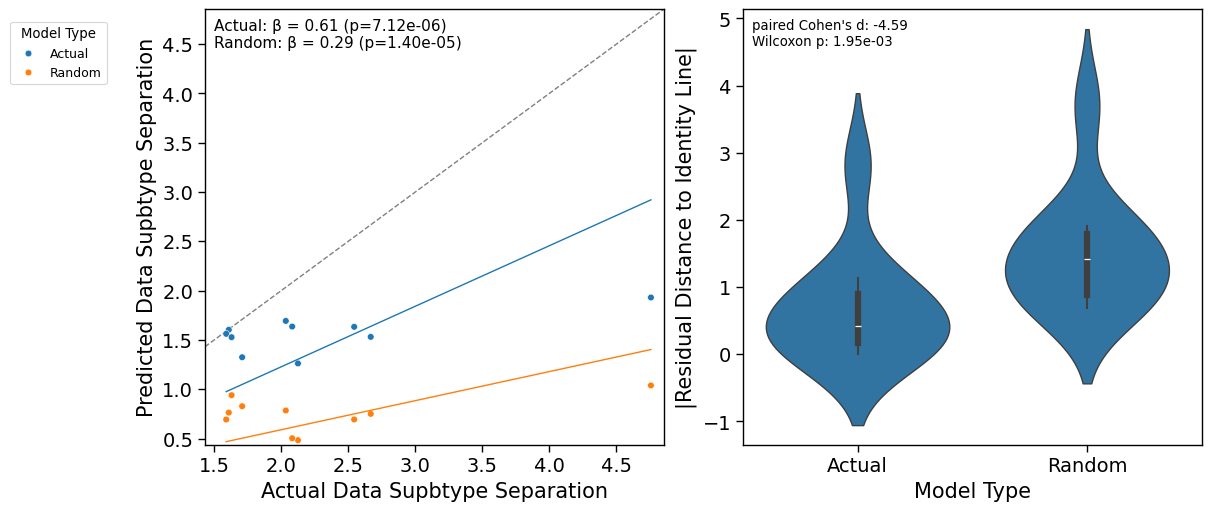

In [13]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5), constrained_layout = True)

j = 0

sns.scatterplot(data = distances_res, x = x_label, y = y_label, hue = 'mod_type', ax = ax[j], zorder = 2)

for mod_type in ['actual', 'random']:
    viz_df = distances_res[distances_res.mod_type == mod_type].copy()

    x = viz_df[x_label].values
    y = viz_df[y_label].values

    # no-intercept OLS
    res = sm.OLS(y, x).fit()
    beta = res.params[0]

    # line through origin: y = beta * x
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = beta * x_line

    ax[j].plot(x_line, y_line, linewidth=1, label=f'{mod_type} fit')



# OLS coefficient
# --- actual model ---
x = distances_res[distances_res.mod_type == 'actual'][x_label].values
y = distances_res[distances_res.mod_type == 'actual'][y_label].values

res = sm.OLS(y, x).fit()   # no intercept
beta_actual = res.params[0]
pval_actual = res.pvalues[0]

# --- no-adversarial model ---
x = distances_res[distances_res.mod_type == 'random'][x_label].values
y = distances_res[distances_res.mod_type == 'random'][y_label].values

res = sm.OLS(y, x).fit()   # no intercept
beta_random = res.params[0]
pval_random = res.pvalues[0]

ax[j].text(
    0.02, 0.98,
    "{}: β = {:.2f} (p={:.2e})\n{}: β = {:.2f} (p={:.2e})".format(
        'Actual', beta_actual, pval_actual,
        'Random', beta_random, pval_random
    ),
    transform = ax[j].transAxes,
    ha = "left",
    va = "top", 
    fontsize = 11, 
)

ax[j].set_xlabel('Actual Data Supbtype Separation')
ax[j].set_ylabel('Predicted Data Supbtype Separation')

x_min, x_max = distances_res[x_label].min(), distances_res[x_label].max()
y_min, y_max = distances_res[y_label].min(), distances_res[y_label].max()

ax[j].set_xlim(x_min, x_max)
ax[j].set_ylim(y_min, y_max)

# identity line
x_min, x_max = distances_res[x_label].min(), distances_res[x_label].max()
y_min, y_max = distances_res[y_label].min(), distances_res[y_label].max()

x_min *= 0.9
y_min*=0.9
ax_max = max(y_max, x_max) * 1.02

ax[j].set_xlim(x_min, ax_max)
ax[j].set_ylim(y_min, ax_max)

# clip only on the lower end
diag_min = max(x_min, y_min)

ax[j].plot(
    [diag_min, ax_max],
    [diag_min, ax_max],
    linestyle="--",
    color="gray",
    linewidth=1,
    zorder=0
)

handles, labels = ax[j].get_legend_handles_labels()
ax[j].legend(
    handles = handles, labels = ['Actual', 'Random'], title = 'Model Type', 
    loc="center right",
    bbox_to_anchor=(-0.2, 0.9),
    frameon=True
)


j = 1
a = distances_res[distances_res.mod_type == 'actual']['error'].values
b = distances_res[distances_res.mod_type == 'random']['error'].values
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b).pvalue


sns.violinplot(data = distances_res, x = 'mod_type', y = 'error', ax = ax[j])
ax[j].set_xlabel('Model Type')


ax[j].text(
    0.02, 0.98,
    f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ticks = ax[j].get_xticks()
ax[j].set_xticks(ticks)
ax[j].set_xticklabels(['Actual', 'Random'])
ax[j].set_ylabel('|Residual Distance to Identity Line|')
;

In [14]:
sr_actual = stats.spearmanr(distances_res_actual[y_label], distances_res_actual[x_label]).statistic
sr_random = stats.spearmanr(distances_res_rand[y_label], distances_res_rand[x_label]).statistic
print('The Spearman correlation between actual and predicted separation is {:.2f} for the actual model and {:.2f} for the random model'.format(sr_actual, sr_random))

The Spearman correlation between actual and predicted separation is 0.28 for the actual model and 0.03 for the random model


We can see that both the *relative* ordering of separation and the magnitude of separation is better, as quantified by the Spearman and beta coefficients, respectively. This indicates that scLEMBAS well captures the magnitude of subtype heterogeneit. Next, let's test for geometry. 

## Geometry

Need to think about this more if going to include, a bit confusing. We can see visually though, that the geometry is preserved. 

In [15]:
# def change_cos_sign(cosine_distance, target_distance, origin_distance):
#     if target_distance > origin_distance:
#         return cosine_distance * -1
#     else:
#         return cosine_distance

# distances_res['cosine_actual'] = distances_res.apply(
#     lambda row: change_cos_sign(
#         row['cosine_actual'],
#         row['target_actual_md'],
#         row['origin_actual_md']
#     ),
#     axis=1
# )

# distances_res['cosine_predicted'] = distances_res.apply(
#     lambda row: change_cos_sign(
#         row['cosine_predicted'],
#         row['target_predicted_md'],
#         row['origin_actual_md']
#     ),
#     axis=1
# )

In [16]:
x_label = 'cosine_actual'
y_label = 'cosine_predicted'

/tmp/ipykernel_1245627/4002519474.py:82: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 2
  ax[j].legend(


''

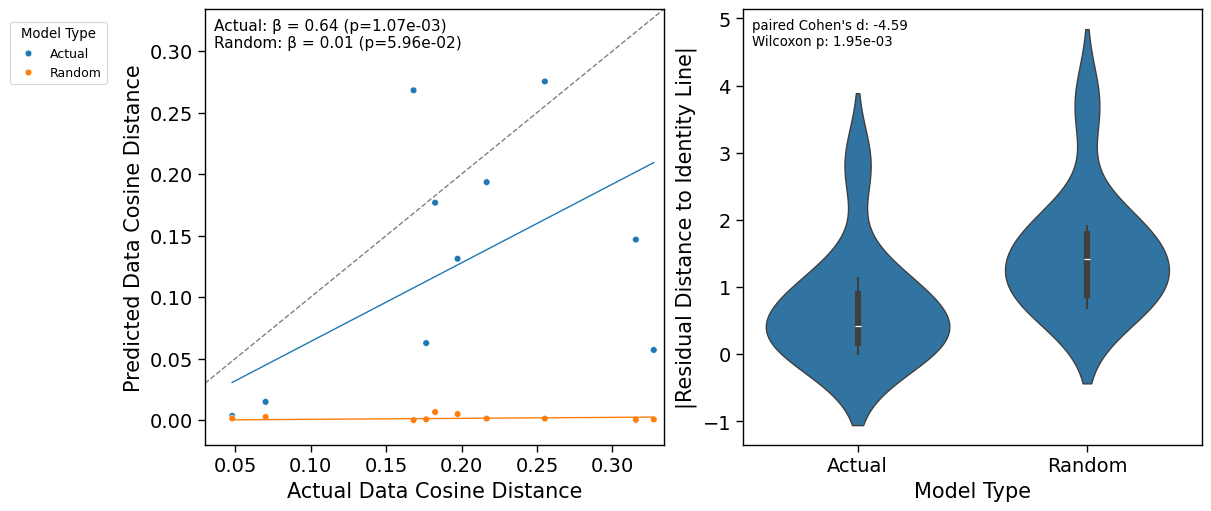

In [28]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5), constrained_layout = True)

j = 0

sns.scatterplot(data = distances_res, x = x_label, y = y_label, hue = 'mod_type', ax = ax[j], zorder = 2)

for mod_type in ['actual', 'random']:
    viz_df = distances_res[distances_res.mod_type == mod_type].copy()

    x = viz_df[x_label].values
    y = viz_df[y_label].values

    # no-intercept OLS
    res = sm.OLS(y, x).fit()
    beta = res.params[0]

    # line through origin: y = beta * x
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = beta * x_line

    ax[j].plot(x_line, y_line, linewidth=1, label=f'{mod_type} fit')



# OLS coefficient
# --- actual model ---
x = distances_res[distances_res.mod_type == 'actual'][x_label].values
y = distances_res[distances_res.mod_type == 'actual'][y_label].values

res = sm.OLS(y, x).fit()   # no intercept
beta_actual = res.params[0]
pval_actual = res.pvalues[0]

# --- no-adversarial model ---
x = distances_res[distances_res.mod_type == 'random'][x_label].values
y = distances_res[distances_res.mod_type == 'random'][y_label].values

res = sm.OLS(y, x).fit()   # no intercept
beta_random = res.params[0]
pval_random = res.pvalues[0]

ax[j].text(
    0.02, 0.98,
    "{}: β = {:.2f} (p={:.2e})\n{}: β = {:.2f} (p={:.2e})".format(
        'Actual', beta_actual, pval_actual,
        'Random', beta_random, pval_random
    ),
    transform = ax[j].transAxes,
    ha = "left",
    va = "top", 
    fontsize = 11, 
)

ax[j].set_xlabel('Actual Data Cosine Distance')
ax[j].set_ylabel('Predicted Data Cosine Distance')


# identity line
x_min, x_max = distances_res[x_label].min(), distances_res[x_label].max()
y_min, y_max = distances_res[y_label].min(), distances_res[y_label].max()

x_min = 0.03 # *= 0.8
y_min = -0.02  #*=0.8
ax_max = max(y_max, x_max) * 1.02

ax[j].set_xlim(x_min, ax_max)
ax[j].set_ylim(y_min, ax_max)

# clip only on the lower end
diag_min = max(x_min, y_min)

ax[j].plot(
    [diag_min, ax_max],
    [diag_min, ax_max],
    linestyle="--",
    color="gray",
    linewidth=1,
    zorder=0
)

handles, labels = ax[j].get_legend_handles_labels()
ax[j].legend(
    handles = handles, labels = ['Actual', 'Random'], title = 'Model Type', 
    loc="center right",
    bbox_to_anchor=(-0.2, 0.9),
    frameon=True
)


j = 1
a = distances_res[distances_res.mod_type == 'actual']['error'].values
b = distances_res[distances_res.mod_type == 'random']['error'].values
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b).pvalue


sns.violinplot(data = distances_res, x = 'mod_type', y = 'error', ax = ax[j])
ax[j].set_xlabel('Model Type')


ax[j].text(
    0.02, 0.98,
    f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ticks = ax[j].get_xticks()
ax[j].set_xticks(ticks)
ax[j].set_xticklabels(['Actual', 'Random'])
ax[j].set_ylabel('|Residual Distance to Identity Line|')
;

In [29]:
sr_actual = stats.spearmanr(distances_res_actual[y_label], distances_res_actual[x_label]).statistic
sr_random = stats.spearmanr(distances_res_rand[y_label], distances_res_rand[x_label]).statistic
print('The Spearman correlation between actual and predicted separation is {:.2f} for the actual model and {:.2f} for the random model'.format(sr_actual, sr_random))


The Spearman correlation between actual and predicted separation is 0.37 for the actual model and -0.32 for the random model


We see that both the relative geometry and magnitude of subtype heterogeneity is preserved, globally across perturbation shift types, relative to random. 